## Finetune Qwen3.5 - 2B with TuringQ 

### Installation

In [1]:
import os, importlib.util
!pip install --upgrade uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0
# Evaluation metrics
!uv pip install rouge-score

Using Python 3.10.20 environment at: /home/sasank-v/anaconda3/envs/finetune
Resolved 4 packages in 693ms                                         
Checked 4 packages in 1ms
Using Python 3.10.20 environment at: /home/sasank-v/anaconda3/envs/finetune
Checked 1 package in 16ms
Using Python 3.10.20 environment at: /home/sasank-v/anaconda3/envs/finetune
Checked 2 packages in 23ms
Using Python 3.10.20 environment at: /home/sasank-v/anaconda3/envs/finetune
Checked 1 package in 7ms


In [2]:
!pip install ipywidgets

In [20]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

### Unsloth

In [3]:
import logging
logging.basicConfig(level=logging.INFO)

from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-2B",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


INFO:httpx:HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen3.5-2B/3c7f026dd8e5a2f34ff18850cbeabcdff7365255/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen3.5-2B "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen3.5-2B/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"


==((====))==  Unsloth 2026.3.18: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.623 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/unslothai/other/revision/main "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unslothai/other/resolve/43d9e0f2f19a5d7836895f648dc0e762816acf77/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unslothai/other/43d9e0f2f19a5d7836895f648dc0e762816acf77/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unslothai/other/resolve/43d9e0f2f19a5d7836895f648dc0e762816acf77/.gitattributes "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/unslothai/other/43d9e0f2f19a5d7836895f648dc0e762816acf77/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unslothai/other/resolve/43d9e0f2f19a5d7836895f648dc0e762816acf77/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unslothai/other/resolve/4

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen3.5-2B/3c7f026dd8e5a2f34ff18850cbeabcdff7365255/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/processor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen3.5-2B/3c7f026dd8e5a2f34ff18850cbeabcdff7365255/processor_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/unsloth/Qwen3.5-2B/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resol

In [4]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # TuringQ is text-only — skip vision layers
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r            = 16,    # The larger, the higher the accuracy, but might overfit
    lora_alpha   = 16,    # Recommended alpha == r at least
    lora_dropout = 0,
    bias         = "none",
    random_state = 3407,
    use_rslora   = False,
    loftq_config = None,
)

model.print_trainable_parameters()

Unsloth: Making `model.base_model.model.model.language_model` require gradients
trainable params: 16,819,200 || all params: 2,230,060,864 || trainable%: 0.7542


<a name="Data"></a>
### Data Prep — TuringQ

We use the **TuringQ** benchmark dataset (`llm-lab/TuringQ`) — a collection of computer-science exam questions sourced from university courses.

**Schema:**
| Column | Description |
|---|---|
| `Question` | CS question text |
| `Answer` | Expected answer |
| `Category` | Topic (Algorithms, OS, Networks, …) |
| `Difficulty` | Easy / Medium / Hard |
| `Source` | Origin textbook / exam |
| `University` | Source university |
| `Type` | Question type |

**Split:** 3 000 train / 1 000 test (4 006 total)

In [5]:
import os, json, random
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm.auto import tqdm

HF_TOKEN   = os.getenv("HF_TOKEN", "")   # set in env or replace with your token
SEED       = 3407
TRAIN_SIZE = 3000
TEST_SIZE  = 1000
# Number of test samples to evaluate before/after training.
# Set to TEST_SIZE for full eval (slower) or a smaller number for quick checks.
EVAL_SAMPLES = 200

random.seed(SEED)
np.random.seed(SEED)

# Load all splits and flatten
raw_ds   = load_dataset("llm-lab/TuringQ", token=HF_TOKEN if HF_TOKEN else None)
all_rows = []
for split_name, split_data in raw_ds.items():
    for row in split_data:
        all_rows.append(dict(row))

df = pd.DataFrame(all_rows)
print(f"Total rows : {len(df)}")
print(f"Columns    : {list(df.columns)}")
df.head(3)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/llm-lab/TuringQ/resolve/main/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/llm-lab/TuringQ/resolve/7f57a851e66f48c47c8b5b9a789ec9ffeda94936/TuringQ.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/llm-lab/TuringQ/llm-lab/TuringQ.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/llm-lab/TuringQ/revision/7f57a851e66f48c47c8b5b9a789ec9ffeda94936 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/llm-lab/TuringQ/resolve/7f57a851e66f48c47c8b5b9a789ec9ffeda94936/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=llm-lab/TuringQ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/llm-lab/TuringQ/tree/7f57a851e66f48c47c8b5b9a789ec9ffeda94936/

Total rows : 4006
Columns    : ['Question', 'Answer', 'Category', 'Difficulty', 'Source', 'University', 'Type']


,Question,Answer,Category,Difficulty,Source,University,Type
0,Show that the following is not regular. L = {w...,"L = {ww^R: w ∈ {a, b}*}. L is the set of all s...",Regular Languages,Level 2,https://www.cs.utexas.edu/~cline/ear/automata/...,The University of Texas at Austin,Analytical
1,Show that the following is not regular. L = {w...,"L = {ww : w ∈ {a, b}*}. We’ll use the pumping ...",Regular Languages,Level 2,CS 341 Homework 9,The University of Texas at Austin,Analytical
2,Show that the following is not regular. L = {w...,"L = {ww' : w ∈ {a, b}*}, where w' stands for w...",Regular Languages,Level 3,CS 341 Homework 9,The University of Texas at Austin,Analytical


In [6]:
# Dataset distributions
print("=== Category distribution ===")
print(df["Category"].value_counts().head(12).to_string())
print("\n=== Difficulty distribution ===")
print(df["Difficulty"].value_counts().to_string())
print("\n=== Type distribution ===")
print(df["Type"].value_counts().to_string())

=== Category distribution ===
Category
Theoretical Concepts          1790
Fundamental Concepts           490
Regular Languages              451
Computability Theory           409
Complexity Theory Concepts     390
Countability Concepts          268
Context-Free Languages         208

=== Difficulty distribution ===
Difficulty
Axiomatic    1790
Level 2      1245
Level 3       641
Level 1       330

=== Type distribution ===
Type
Analytical    1926
Subjective    1283
Objective      795


In [7]:
SYSTEM_PROMPT = (
    "You are an expert computer science professor with deep knowledge across:\n"
    "- Data Structures & Algorithms\n"
    "- Computer Architecture & Operating Systems\n"
    "- Computer Networks & Distributed Systems\n"
    "- Database Management Systems\n"
    "- Theory of Computation\n"
    "- Software Engineering & Programming Languages\n"
    "- Machine Learning & AI\n\n"
    "Give precise, technically accurate, concise answers. Never refuse a CS question."
)


def row_to_conversation(row):
    """Convert a TuringQ row to Unsloth conversation format (text-only, no image)."""
    question   = str(row.get("Question",   "")).strip()
    answer     = str(row.get("Answer",     "")).strip()
    category   = str(row.get("Category",   "")).strip()
    difficulty = str(row.get("Difficulty", "")).strip()

    if not question or not answer:
        return None

    meta = ""
    if category:   meta += f"[Topic: {category}]"
    if difficulty: meta += f" [Difficulty: {difficulty}]"
    user_text = f"{SYSTEM_PROMPT}\n\n{meta}\n{question}".strip() if meta \
                else f"{SYSTEM_PROMPT}\n\n{question}"

    return {
        "messages": [
            {"role": "user",      "content": [{"type": "text", "text": user_text}]},
            {"role": "assistant", "content": [{"type": "text", "text": answer}]},
        ]
    }


all_convs = [row_to_conversation(r) for r in all_rows]
all_convs = [c for c in all_convs if c is not None]

random.shuffle(all_convs)
assert len(all_convs) >= TRAIN_SIZE + TEST_SIZE

train_dataset = all_convs[:TRAIN_SIZE]
test_dataset  = all_convs[TRAIN_SIZE : TRAIN_SIZE + TEST_SIZE]

print(f"Valid examples : {len(all_convs)}")
print(f"Train          : {len(train_dataset)}")
print(f"Test           : {len(test_dataset)}")

# Preview one conversation
print("\n--- Sample conversation (truncated) ---")
sample = train_dataset[0]
print("User:",      sample["messages"][0]["content"][0]["text"][:300])
print("Assistant:", sample["messages"][1]["content"][0]["text"][:200])

Valid examples : 4006
Train          : 3000
Test           : 1000

--- Sample conversation (truncated) ---
User: You are an expert computer science professor with deep knowledge across:
- Data Structures & Algorithms
- Computer Architecture & Operating Systems
- Computer Networks & Distributed Systems
- Database Management Systems
- Theory of Computation
- Software Engineering & Programming Languages
- Machine
Assistant: There exists a plaything that all of the dogs have.


<a name="BaseEval"></a>
### Base Model Evaluation (Before Fine-Tuning)

We run the **unmodified** Qwen3.5-2B on `EVAL_SAMPLES` questions from the test split and record:
- **ROUGE-L** (longest common subsequence recall) — standard for open-ended QA
- **Token-F1** — token overlap between prediction and gold answer
- **Exact-match** (normalised)

We store these predictions so we can compare them side-by-side with the fine-tuned model later.

In [10]:
from rouge_score import rouge_scorer
from transformers import TextStreamer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)


def normalize(text: str) -> str:
    """Lowercase + collapse whitespace."""
    import re
    return re.sub(r"\s+", " ", text.lower().strip())


def token_f1(pred: str, gold: str) -> float:
    p_toks = set(normalize(pred).split())
    g_toks = set(normalize(gold).split())
    if not p_toks or not g_toks:
        return 0.0
    common = p_toks & g_toks
    if not common:
        return 0.0
    prec = len(common) / len(p_toks)
    rec  = len(common) / len(g_toks)
    return 2 * prec * rec / (prec + rec)


def exact_match(pred: str, gold: str) -> float:
    return float(normalize(pred) == normalize(gold))


from PIL import Image
import numpy as np

# dummy image (black image)
dummy_image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))

def generate_answer(question_user_text: str, max_new_tokens=200):
    messages = [
        {"role": "user", "content": [
            {"type": "image"},  # REQUIRED
            {"type": "text", "text": question_user_text}
        ]}
    ]

    input_text = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True
    )

    inputs = tokenizer(
        dummy_image,   # ✅ ALWAYS pass an image
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=1.5,
            min_p=0.1,
        )

    new_tokens = out[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def evaluate_on_test(dataset_split, label="Model", n=EVAL_SAMPLES):
    """Run generation on n test examples and return per-sample results + aggregate metrics."""
    results = []
    subset  = dataset_split[:n]

    for ex in tqdm(subset, desc=f"Evaluating {label}"):
        user_text = ex["messages"][0]["content"][0]["text"]
        gold      = ex["messages"][1]["content"][0]["text"]

        pred      = generate_answer(user_text)

        rl   = scorer.score(normalize(gold), normalize(pred))["rougeL"].fmeasure
        tf1  = token_f1(pred, gold)
        em   = exact_match(pred, gold)

        results.append({
            "user_text": user_text,
            "gold":      gold,
            "pred":      pred,
            "rougeL":    rl,
            "token_f1":  tf1,
            "exact_match": em,
        })

    df_res = pd.DataFrame(results)
    metrics = {
        "ROUGE-L":     df_res["rougeL"].mean(),
        "Token-F1":    df_res["token_f1"].mean(),
        "Exact-Match": df_res["exact_match"].mean(),
        "n_samples":   len(df_res),
    }
    return df_res, metrics

INFO:absl:Using default tokenizer.


In [11]:
# Switch to inference mode before evaluating the base model
FastVisionModel.for_inference(model)

print(f"Running base model evaluation on {EVAL_SAMPLES} test samples...")
base_df, base_metrics = evaluate_on_test(test_dataset, label="Base")

print("\n=== Base Model Metrics ===")
for k, v in base_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Running base model evaluation on 200 test samples...


Evaluating Base:   0%|          | 0/200 [00:00<?, ?it/s]


=== Base Model Metrics ===
  ROUGE-L: 0.1862
  Token-F1: 0.2303
  Exact-Match: 0.0000
  n_samples: 200


In [12]:
# Quick qualitative look at 3 base-model predictions
print("=== Base Model — Sample Predictions ===")
for i in range(3):
    row = base_df.iloc[i]
    # Show just the question part (strip the system prompt)
    q = row["user_text"].split("\n\n", 1)[-1][:200]
    print(f"\n[{i+1}] Question  : {q}")
    print(f"     Gold      : {row['gold'][:200]}")
    print(f"     Predicted : {row['pred'][:200]}")
    print(f"     ROUGE-L={row['rougeL']:.3f}  Token-F1={row['token_f1']:.3f}")

=== Base Model — Sample Predictions ===

[1] Question  : Give precise, technically accurate, concise answers. Never refuse a CS question.

[Topic: Regular Languages] [Difficulty: Level 2]
Let Σ = {a, b}. For each regular expression, if the set given explain
     Gold      : To prove that the given regular expression `(a∗ ∪ b∗)∗bb(a ∪ b)∗` does not generate the language `C = {w ∈ Σ∗ | w starts or ends with bb}`, we need to find a counterexample, which is a string that bel
     Predicted : **False**

**Reasoning:**

The regular expression `(a∗ ∪ b∗)∗bb(a ∪ b)∗` is syntactically invalid in standard regular expression notation.

- The symbol `∗` is used to denote the Kleene star (zero or 
     ROUGE-L=0.271  Token-F1=0.244

[2] Question  : Give precise, technically accurate, concise answers. Never refuse a CS question.

[Topic: Fundamental Concepts] [Difficulty: Level 1]
Translate each statement as indicated, using the set of dogs {Bisc
     Gold      : "It is not the case that all dogs ar

<a name="Train"></a>
### Train the Model

We train on 3 000 TuringQ questions for 3 epochs using `UnslothVisionDataCollator` (required when using `FastVisionModel` even for text-only tasks).

Key SFTConfig notes:
- `max_length` (not `max_seq_length`) is the correct parameter
- `remove_unused_columns = False`, `dataset_text_field = ""`, `dataset_kwargs = {"skip_prepare_dataset": True}` are all required

In [13]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)  # Enable for training!

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),  # Must use!
    train_dataset = train_dataset,
    args          = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,    # effective batch = 8
        warmup_steps                = 5,
        num_train_epochs            = 3,    # full training run
        # max_steps = 30,                   # uncomment for a quick smoke-test
        learning_rate               = 2e-4,
        logging_steps               = 10,
        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "cosine",
        seed                        = 3407,
        output_dir                  = "outputs",
        report_to                   = "none",

        # ── Required for FastVisionModel + UnslothVisionDataCollator ──────────
        remove_unused_columns       = False,
        dataset_text_field          = "",
        dataset_kwargs              = {"skip_prepare_dataset": True},
        max_length                  = 1024,  # max_length, NOT max_seq_length
        # ─────────────────────────────────────────────────────────────────────

        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
    ),
)

Unsloth: Model does not have a default image size - using 512


In [14]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA GeForce RTX 4060 Laptop GPU. Max memory = 7.623 GB.
3.973 GB of memory reserved.


In [15]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,000 | Num Epochs = 3 | Total steps = 1,125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 16,819,200 of 2,230,060,864 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,1.599920
20,1.142787
30,0.972518
40,0.929211
50,1.038190
60,0.954136
70,0.913133
80,0.899624
90,0.942814
100,0.925123


INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen3.5-2B/3c7f026dd8e5a2f34ff18850cbeabcdff7365255/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/unsloth/Qwen3.5-2B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/unsloth/Qwen3.5-2B/3c7f026dd8e5a2f34ff18850cbeabcdff7365255/config.json "HTTP/1.1 200 OK"
/home/sasank-v/anaconda3/envs/finetune/lib/python3.10/site-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error [Errno -2] Name or service not known - silently ignoring the lookup for the file config.json in unsloth/Qwen3.5-2B.
  warnings.warn(
/home/sasank-v/anaconda3/envs/finetune/lib/python3.10/site-packages/peft/utils/save_and_load.py:295: UserWa

In [16]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

2369.7651 seconds used for training.
39.5 minutes used for training.
Peak reserved memory = 5.158 GB.
Peak reserved memory for training = 1.185 GB.
Peak reserved memory % of max memory = 67.664 %.
Peak reserved memory for training % of max memory = 15.545 %.


<a name="Inference"></a>
### Fine-Tuned Model Evaluation (After Fine-Tuning)

We run the **same** `EVAL_SAMPLES` test questions through the fine-tuned model and collect the same metrics for a fair comparison.

In [17]:
FastVisionModel.for_inference(model)  # Enable for inference!

print(f"Running fine-tuned model evaluation on {EVAL_SAMPLES} test samples...")
ft_df, ft_metrics = evaluate_on_test(test_dataset, label="Fine-Tuned")

print("\n=== Fine-Tuned Model Metrics ===")
for k, v in ft_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Running fine-tuned model evaluation on 200 test samples...


Evaluating Fine-Tuned:   0%|          | 0/200 [00:00<?, ?it/s]


=== Fine-Tuned Model Metrics ===
  ROUGE-L: 0.3358
  Token-F1: 0.3970
  Exact-Match: 0.0100
  n_samples: 200


<a name="Compare"></a>
### Results Comparison — Base vs Fine-Tuned

In [18]:
# ── Aggregate metrics table ───────────────────────────────────────────────────
metric_names = ["ROUGE-L", "Token-F1", "Exact-Match"]

comparison_df = pd.DataFrame({
    "Metric":       metric_names,
    "Base Model":   [base_metrics[m] for m in metric_names],
    "Fine-Tuned":   [ft_metrics[m]   for m in metric_names],
})
comparison_df["Delta"]    = comparison_df["Fine-Tuned"] - comparison_df["Base Model"]
comparison_df["Δ %"]      = (comparison_df["Delta"] / (comparison_df["Base Model"] + 1e-9) * 100).round(1)
comparison_df[["Base Model", "Fine-Tuned", "Delta"]] = \
    comparison_df[["Base Model", "Fine-Tuned", "Delta"]].round(4)

print("=" * 60)
print("  BASE MODEL  vs  FINE-TUNED  —  Test Set Comparison")
print(f"  Evaluated on {EVAL_SAMPLES} samples from the 1 000-sample test split")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

  BASE MODEL  vs  FINE-TUNED  —  Test Set Comparison
  Evaluated on 200 samples from the 1 000-sample test split
     Metric  Base Model  Fine-Tuned  Delta          Δ %
    ROUGE-L      0.1862      0.3358 0.1496         80.4
   Token-F1      0.2303      0.3970 0.1668         72.4
Exact-Match      0.0000      0.0100 0.0100 1000000000.0


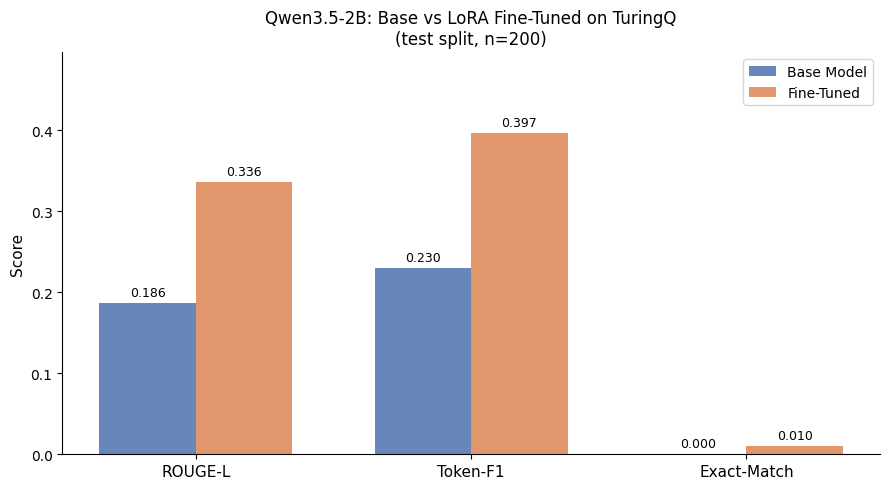

Saved → comparison_metrics.png


In [21]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

x       = np.arange(len(metric_names))
width   = 0.35
base_v  = [base_metrics[m] for m in metric_names]
ft_v    = [ft_metrics[m]   for m in metric_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars1   = ax.bar(x - width/2, base_v, width, label="Base Model",  color="#4C72B0", alpha=0.85)
bars2   = ax.bar(x + width/2, ft_v,   width, label="Fine-Tuned",  color="#DD8452", alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(f"Qwen3.5-2B: Base vs LoRA Fine-Tuned on TuringQ\n"
             f"(test split, n={EVAL_SAMPLES})", fontsize=12)
ax.set_ylim(0, max(max(base_v), max(ft_v)) * 1.25)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_metrics.png")

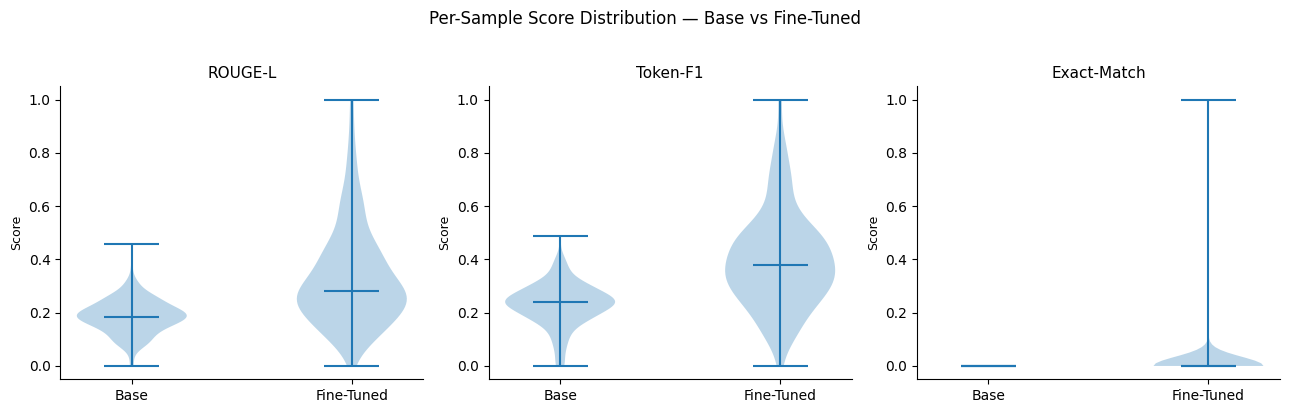

Saved → distribution_comparison.png


In [22]:
# ── Per-sample ROUGE-L distribution (violin / box) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_cols = ["rougeL", "token_f1", "exact_match"]
metric_lbls = ["ROUGE-L", "Token-F1", "Exact-Match"]

for ax, col, lbl in zip(axes, metric_cols, metric_lbls):
    ax.violinplot(
        [base_df[col].values, ft_df[col].values],
        positions=[1, 2],
        showmedians=True,
        showextrema=True,
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Base", "Fine-Tuned"], fontsize=10)
    ax.set_title(lbl, fontsize=11)
    ax.set_ylabel("Score", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Per-Sample Score Distribution — Base vs Fine-Tuned", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → distribution_comparison.png")

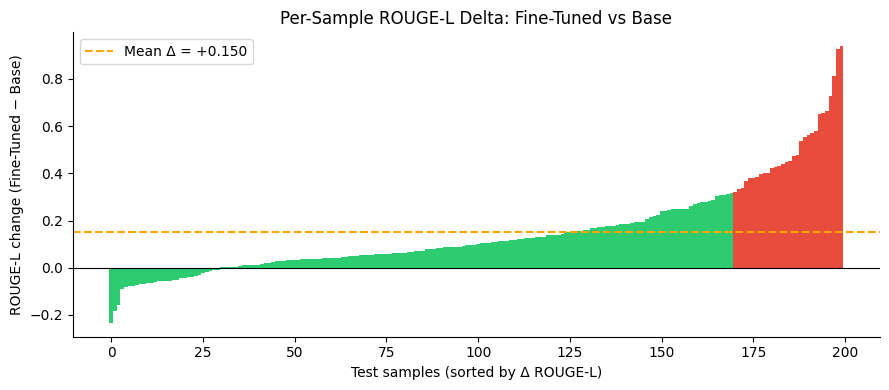

Improved on : 170 / 200 samples
Degraded on : 30 / 200 samples
Unchanged   : 0 / 200 samples


In [23]:
# ── ROUGE-L improvement scatter (per sample) ─────────────────────────────────
delta_rl = ft_df["rougeL"].values - base_df["rougeL"].values

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in delta_rl]
ax.bar(range(len(delta_rl)), sorted(delta_rl), color=sorted(colors, key=lambda c: c == "#e74c3c"),
       width=1.0, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(delta_rl.mean(), color="orange", linewidth=1.5, linestyle="--",
           label=f"Mean Δ = {delta_rl.mean():+.3f}")
ax.set_xlabel("Test samples (sorted by Δ ROUGE-L)", fontsize=10)
ax.set_ylabel("ROUGE-L change (Fine-Tuned − Base)", fontsize=10)
ax.set_title("Per-Sample ROUGE-L Delta: Fine-Tuned vs Base", fontsize=12)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("rougeL_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Improved on : {(delta_rl > 0).sum()} / {len(delta_rl)} samples")
print(f"Degraded on : {(delta_rl < 0).sum()} / {len(delta_rl)} samples")
print(f"Unchanged   : {(delta_rl == 0).sum()} / {len(delta_rl)} samples")

In [24]:
# ── Qualitative side-by-side comparison on 5 test samples ────────────────────
print("=" * 70)
print("  QUALITATIVE COMPARISON — 5 Test Samples")
print("=" * 70)

for i in range(5):
    base_row = base_df.iloc[i]
    ft_row   = ft_df.iloc[i]

    # Strip system prompt to show just the question
    q = base_row["user_text"].split("\n\n", 1)[-1][:300]

    print(f"\n[{i+1}] QUESTION   : {q}")
    print(f"     GOLD       : {base_row['gold'][:250]}")
    print(f"     BASE       : {base_row['pred'][:250]}")
    print(f"     FINE-TUNED : {ft_row['pred'][:250]}")
    print(f"     ROUGE-L    : Base={base_row['rougeL']:.3f}  "
          f"Fine-Tuned={ft_row['rougeL']:.3f}  "
          f"Δ={ft_row['rougeL'] - base_row['rougeL']:+.3f}")
    print(f"     Token-F1   : Base={base_row['token_f1']:.3f}  "
          f"Fine-Tuned={ft_row['token_f1']:.3f}  "
          f"Δ={ft_row['token_f1'] - base_row['token_f1']:+.3f}")
    print("-" * 70)

  QUALITATIVE COMPARISON — 5 Test Samples

[1] QUESTION   : Give precise, technically accurate, concise answers. Never refuse a CS question.

[Topic: Regular Languages] [Difficulty: Level 2]
Let Σ = {a, b}. For each regular expression, if the set given explains the given regular expression write True, or saying False if the language of the regular expression
     GOLD       : To prove that the given regular expression `(a∗ ∪ b∗)∗bb(a ∪ b)∗` does not generate the language `C = {w ∈ Σ∗ | w starts or ends with bb}`, we need to find a counterexample, which is a string that belongs to the language `C` but cannot be generated b
     BASE       : **False**

**Reasoning:**

The regular expression `(a∗ ∪ b∗)∗bb(a ∪ b)∗` is syntactically invalid in standard regular expression notation.

- The symbol `∗` is used to denote the Kleene star (zero or more occurrences of the preceding element).
- Howe
     FINE-TUNED : False. The regular expression (a∗ ∪ b∗)∗bb(a ∪ b)∗ matches any string that contains

In [25]:
# ── Save full results to CSV for offline analysis ────────────────────────────
base_df_out = base_df[["gold", "pred", "rougeL", "token_f1", "exact_match"]].copy()
base_df_out.columns = ["gold", "base_pred", "base_rougeL", "base_token_f1", "base_em"]

ft_df_out = ft_df[["pred", "rougeL", "token_f1", "exact_match"]].copy()
ft_df_out.columns = ["ft_pred", "ft_rougeL", "ft_token_f1", "ft_em"]

combined = pd.concat([base_df_out.reset_index(drop=True),
                      ft_df_out.reset_index(drop=True)], axis=1)
combined.to_csv("turingq_comparison_results.csv", index=False)
print(f"Full results saved → turingq_comparison_results.csv  ({len(combined)} rows)")
combined.head(3)

Full results saved → turingq_comparison_results.csv  (200 rows)


,gold,base_pred,base_rougeL,base_token_f1,base_em,ft_pred,ft_rougeL,ft_token_f1,ft_em
0,To prove that the given regular expression `(a...,**False**\n\n**Reasoning:**\n\nThe regular exp...,0.271293,0.244186,0.0,False. The regular expression (a∗ ∪ b∗)∗bb(a ∪...,0.197719,0.300000,0.0
1,"""It is not the case that all dogs are wet."" Or...",**Statement IV: ¬∀z: W(z)**\n\n**Translation:*...,0.262295,0.241758,0.0,It is not the case that every dog is a walker....,0.540541,0.518519,0.0
2,"No, according to the theorem, every CFL is in P.",Yes.\n\n**Answer:** \nThere exist Context-Fre...,0.084507,0.100000,0.0,"Yes, there are Context-Free Languages that are...",0.243902,0.285714,0.0


<a name="Save"></a>
### Saving the Fine-Tuned Model

To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, see below!

In [26]:
model.save_pretrained("qwen_turingq_lora")   # Local saving
tokenizer.save_pretrained("qwen_turingq_lora")
# model.push_to_hub("your_name/qwen_turingq_lora", token = "YOUR_HF_TOKEN")
# tokenizer.push_to_hub("your_name/qwen_turingq_lora", token = "YOUR_HF_TOKEN")
print("Adapter saved to qwen_turingq_lora/")

/home/sasank-v/anaconda3/envs/finetune/lib/python3.10/site-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error [Errno -2] Name or service not known - silently ignoring the lookup for the file config.json in unsloth/Qwen3.5-2B.
  warnings.warn(
/home/sasank-v/anaconda3/envs/finetune/lib/python3.10/site-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in unsloth/Qwen3.5-2B - will assume that the vocabulary was not modified.
  warnings.warn(


Adapter saved to qwen_turingq_lora/


Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [27]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name   = "qwen_turingq_lora",
        load_in_4bit = True,
    )
    FastVisionModel.for_inference(model)

### Saving to float16 for VLLM

In [28]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion

In [29]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune",
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )